# Trabajo Final Integrador
# Parte III - Estadística No Paramétrica

Esta parte desarrolla el punto 11 y 12 del enunciado utilizando **únicamente** las herramientas vistas en la Unidad 4: QQ-Plot, prueba de Shapiro-Wilk y Test del Signo.

## Lectura de los datos y cálculo de los residuos
Se vuelve a calcular el modelo lineal para obtener los residuos que serán analizados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("13_Santa_Fe_Vera.csv", sep=";")
df.columns = df.columns.str.strip()

x = df["Temperatura_Abrigo_150cm"]
y = df["Radiacion_Global"]

resultado = stats.linregress(x,y)
y_est = resultado.intercept + resultado.slope*x
residuos = y - y_est

print(residuos.describe())


count    3.970000e+02
mean    -1.431824e-15
std      6.754719e+00
min     -1.803492e+01
25%     -4.573875e+00
50%      1.226927e+00
75%      5.296628e+00
max      1.425765e+01
dtype: float64


## Punto 11 - Verificación gráfica de normalidad (QQ-Plot)

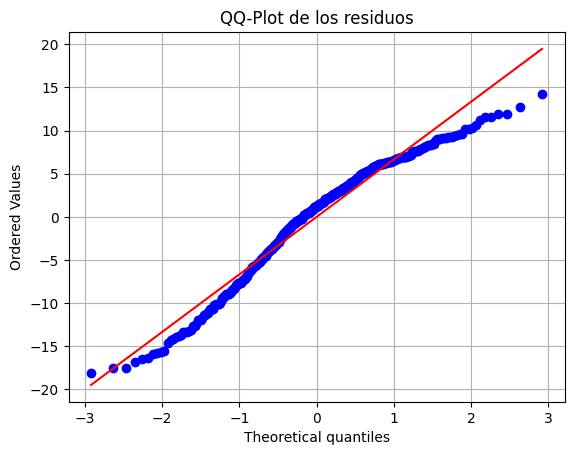

In [ ]:
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQ-Plot de los residuos")
plt.grid(True)
plt.show()


## Test de Shapiro-Wilk

Hipótesis:

- \(H_0\): Los residuos siguen una distribución Normal.
- \(H_1\): Los residuos no siguen una distribución Normal.

Si no se verifica normalidad, se justifica utilizar un procedimiento no paramétrico, tal como se desarrolló en la Unidad 4.


In [ ]:
alpha=0.05

W,p = stats.shapiro(residuos)

print("Estadístico W =",W)
print("p-valor =",p)

if p < alpha:
    print("Se rechaza H0: los residuos no presentan distribución normal.")
else:
    print("No se rechaza H0: no hay evidencia para descartar la normalidad.")


Estadístico W = 0.9623812997116376
p-valor = 1.4761708790877683e-08
Se rechaza H0: los residuos no presentan distribución normal.


## Test del Signo

Siguiendo la metodología desarrollada en clase, se contrasta:

- \(H_0\): La mediana de los residuos es igual a 0.
- \(H_1\): La mediana de los residuos es distinta de 0.

Se utiliza una prueba binomial sobre los signos de los residuos.


In [ ]:
positivos = np.sum(residuos > 0)
n = len(residuos)

print("Cantidad de residuos positivos:", positivos)
print("Cantidad total:", n)

prueba = stats.binomtest(
    k=positivos,
    n=n,
    p=0.5,
    alternative="two-sided"
)

print(prueba)
print("p-valor =", prueba.pvalue)

if prueba.pvalue < alpha:
    print("Decisión: Se rechaza H0.")
    print("La mediana de los residuos difiere significativamente de cero.")
else:
    print("Decisión: No se rechaza H0.")
    print("No existe evidencia para afirmar que la mediana difiere de cero.")


Cantidad de residuos positivos: 227
Cantidad total: 397
BinomTestResult(k=227, n=397, alternative='two-sided', statistic=0.5717884130982368, pvalue=0.004882911609250226)
p-valor = 0.004882911609250226
Decisión: Se rechaza H0.
La mediana de los residuos difiere significativamente de cero.


## Comparación con la Parte II

En la Parte II se utilizó un método paramétrico (regresión lineal y contraste sobre la pendiente).
En esta parte se aplicó un procedimiento no paramétrico siguiendo el contenido de la Unidad 4.

Ambos análisis permiten comparar las conclusiones obtenidas utilizando enfoques diferentes.


# Punto 12 - Conclusión General

La Parte II permitió estudiar la relación lineal entre la temperatura y la radiación global mediante un modelo de regresión.

La Parte III complementó dicho análisis utilizando herramientas no paramétricas desarrolladas en clase (QQ-Plot, Shapiro-Wilk y Test del Signo). De esta manera se evaluó la validez de los supuestos del modelo y se incorporó un análisis alternativo cuando dichos supuestos no se cumplen, respetando la metodología vista durante la cursada.
